# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Adriano Deshon
- **Email:** adrianodeshon25@gmail.com
- **ID Dicoding:** adriano_deshon

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Pada musim (*season*) apa penyewaan sepeda mencapai angka tertinggi dan terendah, dan bagaimana tren penyewaan sepeda dari bulan ke bulan (*mnth*)?
- **Pertanyaan 2:** Bagaimana perbedaan pola penyewaan sepeda antara pelanggan biasa (*casual*) dan pelanggan terdaftar (*registered*) saat hari kerja (*workingday*) dibandingkan dengan saat hari libur/akhir pekan?
- **Pertanyaan 3 (Analisis Lanjutan):** Bagaimana pengaruh kelompok suhu lingkungan (Dingin, Sejuk, Panas) terhadap rata-rata jumlah penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
# Memuat data day.csv
df = pd.read_csv("https://raw.githubusercontent.com/AdrianoDeshon1012/Submission_Analisis_Data/refs/heads/main/data/day.csv")
# Melihat 5 data pertama
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight**
- Dataset `day.csv` telah berhasil dimuat ke dalam Pandas DataFrame.
- Sekilas dari 5 baris pertama, dataset ini mencatat data harian penyewaan sepeda dengan atribut seperti tanggal (`dteday`), informasi musim (`season`), cuaca (`weathersit`), suhu (`temp`), serta jumlah penyewa baik yang kasual (`casual`), terdaftar (`registered`), maupun totalnya (`cnt`).

### Assessing Data

In [3]:
# Memeriksa tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [4]:
# Memeriksa missing values pada data
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [5]:
# memeriksa jumlah duplikasi pada data
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


In [6]:
# Memeriksa parameter statistik
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Dataset `day.csv` memiliki 731 baris dan 16 kolom.
- Tidak ditemukan *missing values* (semua kolom memiliki 731 nilai *non-null*).
- Tidak ditemukan duplikasi data (jumlah duplikasi = 0).
- Tipe data sudah sesuai, namun beberapa kolom kategori seperti `season`, `mnth`, dan `workingday` masih direpresentasikan dalam bentuk angka numerik sehingga perlu di-*mapping* agar lebih mudah dibaca saat visualisasi.

### Cleaning Data

In [7]:
# Mapping kolom 'season'
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df['season_name'] = df['season'].map(season_mapping)

# Mapping kolom 'workingday'
workingday_mapping = {0: 'Holiday/Weekend', 1: 'Working Day'}
df['workingday_name'] = df['workingday'].map(workingday_mapping)

# Mapping kolom 'mnth'
month_mapping = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
df['month_name'] = df['mnth'].map(month_mapping)

df[['season_name', 'workingday_name', 'month_name']].head()

,season_name,workingday_name,month_name
0,Spring,Holiday/Weekend,Jan
1,Spring,Holiday/Weekend,Jan
2,Spring,Working Day,Jan
3,Spring,Working Day,Jan
4,Spring,Working Day,Jan


**Insight:**
- Kolom kategorik yang berwujud angka telah dikonversi (di-*mapping*) menjadi *string* (teks) yang deskriptif. Misalnya, nilai 1 pada `season` diubah menjadi 'Spring', dan nilai 0 pada `workingday` diubah menjadi 'Holiday/Weekend'.
- Transformasi ini menghasilkan kolom baru (`season_name`, `workingday_name`, `month_name`) yang siap digunakan secara langsung pada proses Exploratory Data Analysis (EDA) dan visualisasi tanpa membingungkan pembaca grafik nantinya.

## Exploratory Data Analysis (EDA)

### Explore Pertanyaan 1

In [8]:
# Melihat total penyewaan berdasarkan musim
df.groupby('season_name')['cnt'].sum().sort_values(ascending=False).reset_index()

,season_name,cnt
0,Fall,1061129
1,Summer,918589
2,Winter,841613
3,Spring,471348


In [9]:
# Melihat total penyewaan berdasarkan bulan
df.groupby('mnth')['cnt'].sum().reset_index()

,mnth,cnt
0,1,134933
1,2,151352
2,3,228920
3,4,269094
4,5,331686
5,6,346342
6,7,344948
7,8,351194
8,9,345991
9,10,322352


### Explore Pertanyaan 2



In [10]:
# Membandingkan rata-rata penyewa casual dan registered pada hari kerja vs hari libur
df.groupby('workingday_name')[['casual', 'registered']].mean().reset_index()

,workingday_name,casual,registered
0,Holiday/Weekend,1371.134199,2959.034632
1,Working Day,606.570000,3978.250000


**Insight:**
- **Eksplorasi Pertanyaan 1:** Berdasarkan agregasi total penyewaan (`cnt`), terlihat bahwa Musim Gugur (*Fall*) mencatat total penyewaan terbanyak (lebih dari 1 juta penyewaan), sementara Musim Semi (*Spring*) adalah yang paling sepi. Dilihat dari pergerakan bulanannya, penyewaan sepeda cenderung meningkat di pertengahan tahun (terutama bulan Juni hingga September) dan menurun di awal serta akhir tahun.
- **Eksplorasi Pertanyaan 2:** Dilihat dari nilai rata-ratanya, pengguna `registered` jauh lebih aktif di hari kerja (*Working Day*) dengan rata-rata nyaris menyentuh angka 4.000 penyewaan per hari, dibandingkan dengan saat hari libur (sekitar 2.900). Sebaliknya, pengguna `casual` justru memiliki rata-rata penyewaan yang lebih tinggi di hari libur/akhir pekan dibandingkan pada hari kerja biasa.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20268\1825378387.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


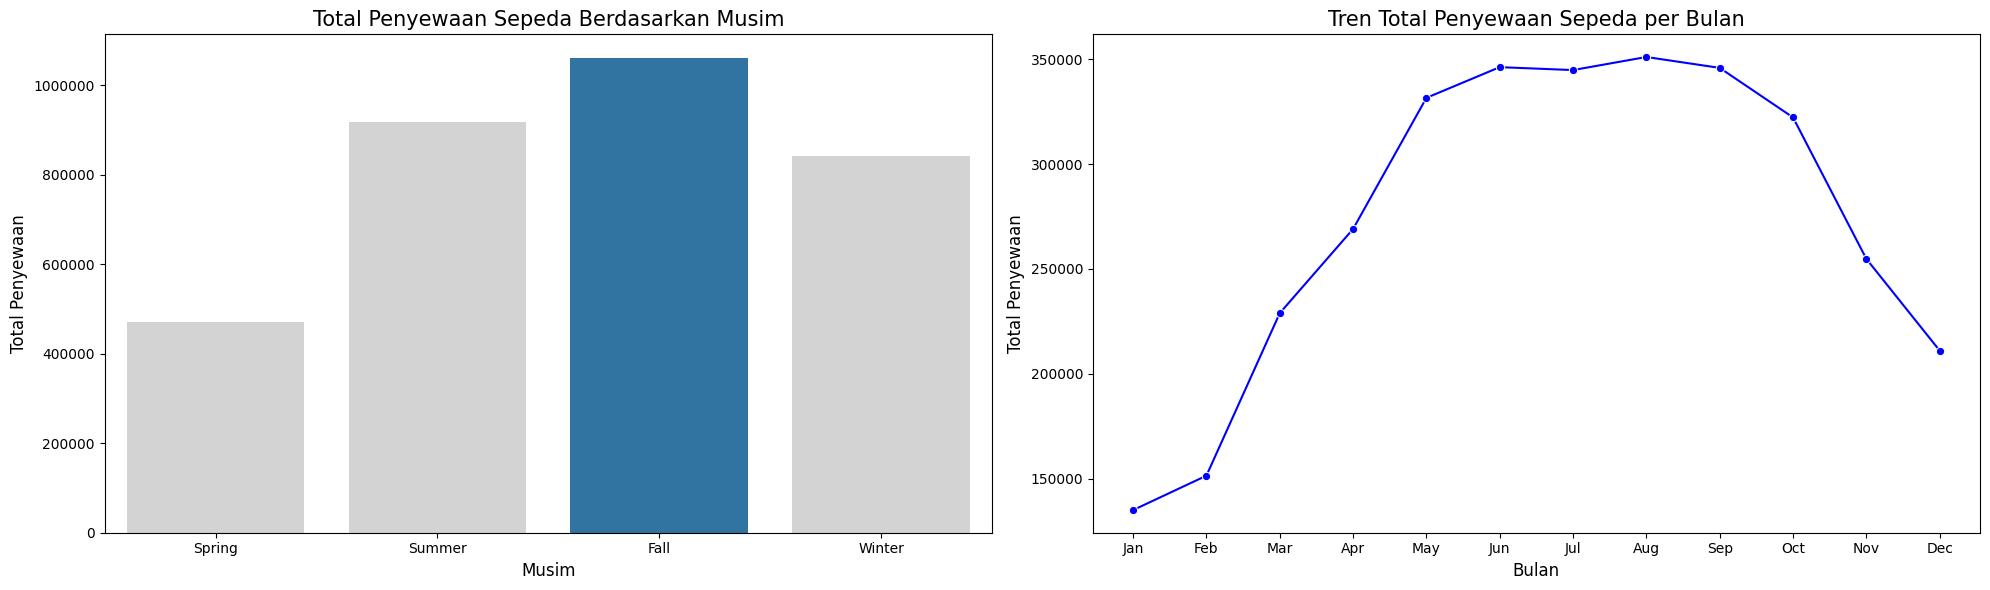

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# 1. Membuat palet warna kustom: 'Fall' berwarna biru dominan, sisanya abu-abu redup
custom_colors = {'Spring': '#D3D3D3', 'Summer': '#D3D3D3', 'Fall': '#1f77b4', 'Winter': '#D3D3D3'}

# Barplot untuk Musim (menggunakan custom_colors)
sns.barplot(
    x='season_name',
    y='cnt',
    data=df,
    estimator=sum,
    errorbar=None,
    ax=ax[0],
    palette=custom_colors # Memanggil warna kustom di sini
)
ax[0].set_title('Total Penyewaan Sepeda Berdasarkan Musim', fontsize=15)
ax[0].set_xlabel('Musim', fontsize=12)
ax[0].set_ylabel('Total Penyewaan', fontsize=12)
ax[0].ticklabel_format(style='plain', axis='y') # Mengubah format 1e6 menjadi angka biasa

# Lineplot untuk Tren Bulanan
sns.lineplot(x='month_name', y='cnt', data=df, estimator=sum, errorbar=None, marker='o', ax=ax[1], color='b')
ax[1].set_title('Tren Total Penyewaan Sepeda per Bulan', fontsize=15)
ax[1].set_xlabel('Bulan', fontsize=12)
ax[1].set_ylabel('Total Penyewaan', fontsize=12)

plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan grafik batang (kiri), terlihat visualisasi yang jelas bahwa musim gugur (*Fall*) menyumbang jumlah penyewaan sepeda tertinggi, melampaui 800.000 penyewaan. Sebaliknya, musim semi (*Spring*) memiliki jumlah penyewaan paling sedikit.
- Grafik garis (kanan) mempertegas temuan tersebut melalui tren bulanan. Kurva menunjukkan pola parabolik di mana penyewaan mulai merangkak naik dari awal tahun, mencapai puncaknya dan stabil pada angka yang tinggi di pertengahan tahun (antara bulan Juni hingga September), lalu mengalami tren penurunan seiring mendekati akhir tahun. Suhu dan cuaca di pertengahan tahun tampaknya sangat mendukung aktivitas bersepeda.


### Pertanyaan 2:

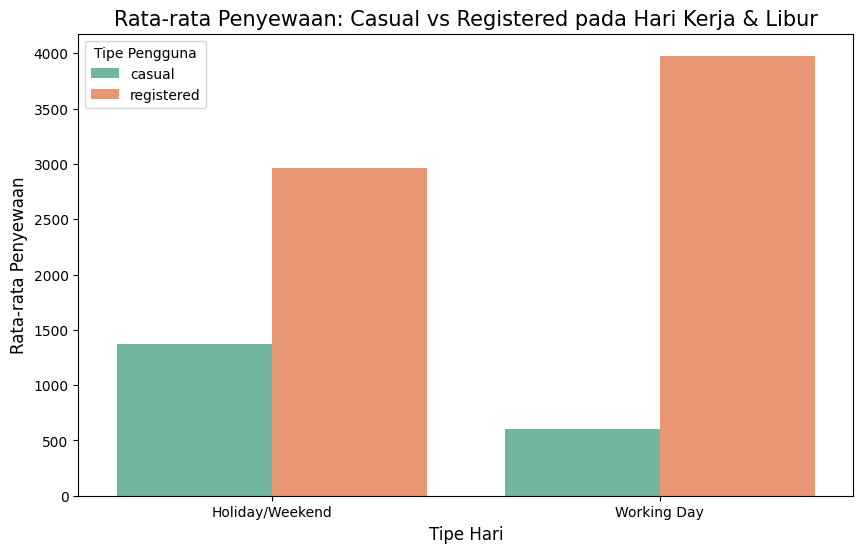

In [12]:
# Melakukan unpivot (melt) agar format data mudah divisualisasikan oleh Seaborn
melted_df = pd.melt(df, id_vars=['workingday_name'], value_vars=['casual', 'registered'],
                    var_name='User_Type', value_name='Average_Rentals')

plt.figure(figsize=(10, 6))
sns.barplot(x='workingday_name', y='Average_Rentals', hue='User_Type', data=melted_df, errorbar=None, palette='Set2')

plt.title('Rata-rata Penyewaan: Casual vs Registered pada Hari Kerja & Libur', fontsize=15)
plt.xlabel('Tipe Hari', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.legend(title='Tipe Pengguna')

plt.show()

**Insight:**
- Grafik batang berkelompok (*grouped bar chart*) di atas memvisualisasikan perbedaan mencolok antara dua kelompok pengguna.
- Batang berwarna hijau (*casual*) menunjukkan bahwa rata-rata penyewaan oleh pelanggan biasa meningkat drastis saat Holiday/Weekend dibandingkan saat hari kerja, memperkuat dugaan bahwa pengguna kasual lebih sering menyewa sepeda untuk rekreasi atau wisata di akhir pekan.
- Di sisi lain, batang berwarna oranye (*registered*) justru menunjukkan pola sebaliknya. Rata-rata penyewaan menjulang jauh lebih tinggi pada kategori *Working Day* dibandingkan saat *Holiday/Weekend*. Hal ini mengonfirmasi bahwa pelanggan yang sudah terdaftar mayoritas menggunakan sepeda untuk rutinitas harian di hari kerja (komuter).

## Analisis Lanjutan (Opsional)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20268\1964273039.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_cluster_df = df.groupby('temp_group')['cnt'].mean().reset_index()


,temp_group,cnt
0,Rendah (Dingin),2595.445714
1,Sedang (Sejuk),4876.659686
2,Tinggi (Panas),5606.850575


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20268\1964273039.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


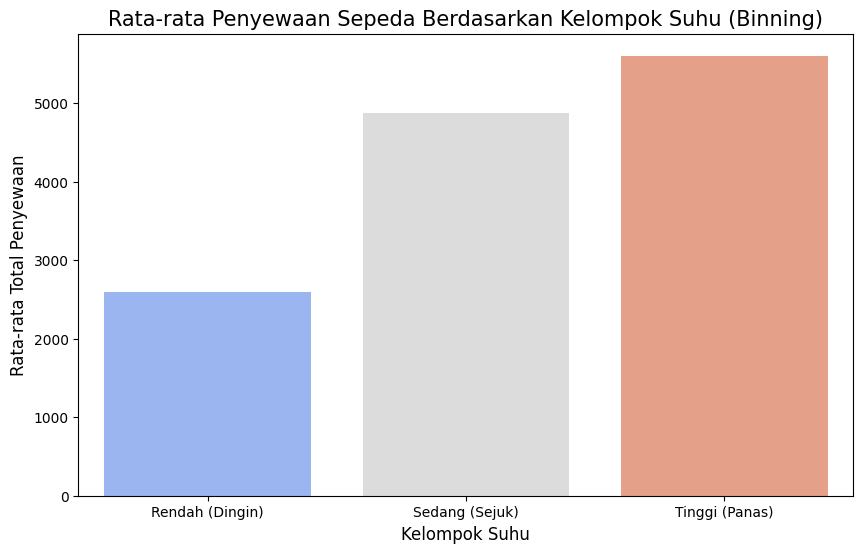

In [13]:
# 1. Melakukan Binning pada kolom 'temp' (Suhu)
bins = [0, 0.33, 0.66, 1.0]
labels = ['Rendah (Dingin)', 'Sedang (Sejuk)', 'Tinggi (Panas)']

# Membuat kolom baru 'temp_group' sebagai hasil clustering manual
df['temp_group'] = pd.cut(df['temp'], bins=bins, labels=labels, include_lowest=True)

# 2. Agregasi untuk melihat rata-rata penyewaan di setiap kelompok suhu
temp_cluster_df = df.groupby('temp_group')['cnt'].mean().reset_index()
display(temp_cluster_df)

# 3. Visualisasi Hasil Clustering
plt.figure(figsize=(10, 6))
sns.barplot(
    x='temp_group',
    y='cnt',
    data=df,
    palette='coolwarm',
    errorbar=None
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kelompok Suhu (Binning)', fontsize=15)
plt.xlabel('Kelompok Suhu', fontsize=12)
plt.ylabel('Rata-rata Total Penyewaan', fontsize=12)

plt.show()

**Insight Analisis Lanjutan (Clustering/Binning):**
- Melalui teknik *binning* tanpa machine learning, kita berhasil mengelompokkan data hari ke dalam 3 *cluster* berdasarkan suhu lingkungannya: Rendah, Sedang, dan Tinggi.
- Dari visualisasi tersebut, teridentifikasi sebuah pola perilaku pelanggan: **Semakin tinggi suhu (semakin hangat/panas cuaca), jumlah penyewaan sepeda justru cenderung semakin meningkat**.
- Hari dengan *cluster* suhu "Rendah (Dingin)" memiliki rata-rata penyewaan yang paling anjlok, membuktikan bahwa suhu dingin merupakan *barrier* (hambatan) utama bagi pelanggan untuk bersepeda.

## Conclusion

- **Conclusion Pertanyaan 1:** Penyewaan sepeda mencapai titik puncaknya pada musim gugur (*Fall*), sedangkan penyewaan terendah terjadi pada musim semi (*Spring*). Jika dilihat dari tren bulanan, jumlah penyewaan mulai merangkak naik secara perlahan dari bulan Januari, memuncak pada periode bulan Juni hingga September, dan kemudian kembali menurun menjelang akhir tahun (Oktober hingga Desember).

- **Conclusion Pertanyaan 2:** Terdapat perbedaan perilaku yang sangat kontras antara pengguna biasa (*casual*) dan terdaftar (*registered*). Rata-rata pengguna *registered* sangat mendominasi penyewaan pada saat hari kerja (*Working Day*), yang mengindikasikan mereka rutin menggunakan sepeda untuk mobilitas harian (seperti berangkat kerja atau sekolah). Sebaliknya, pengguna *casual* menunjukkan lonjakan penyewaan rata-rata yang cukup signifikan pada saat akhir pekan/hari libur (*Holiday/Weekend*), yang kemungkinan besar digunakan untuk rekreasi atau sekadar berkeliling santai di hari libur.
- **Conclusion Pertanyaan 3 (Analisis Lanjutan):**
Berdasarkan hasil pengelompokan (*clustering/binning*) pada variabel suhu, terbukti bahwa kondisi suhu sangat memengaruhi minat pelanggan untuk menyewa sepeda. Rata-rata penyewaan paling rendah terjadi pada kelompok suhu "Rendah (Dingin)". Sebaliknya, jumlah rata-rata penyewaan berangsur-angsur meningkat dan mencapai titik tertinggi pada saat suhu berada di kelompok "Tinggi (Panas)". Cuaca yang lebih hangat mendorong lebih banyak orang untuk beraktivitas di luar ruangan menggunakan sepeda.